In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Problem 1: Line plots

In [7]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays)  
#### NO PANDAS ALLOWED!
#########################################################

t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

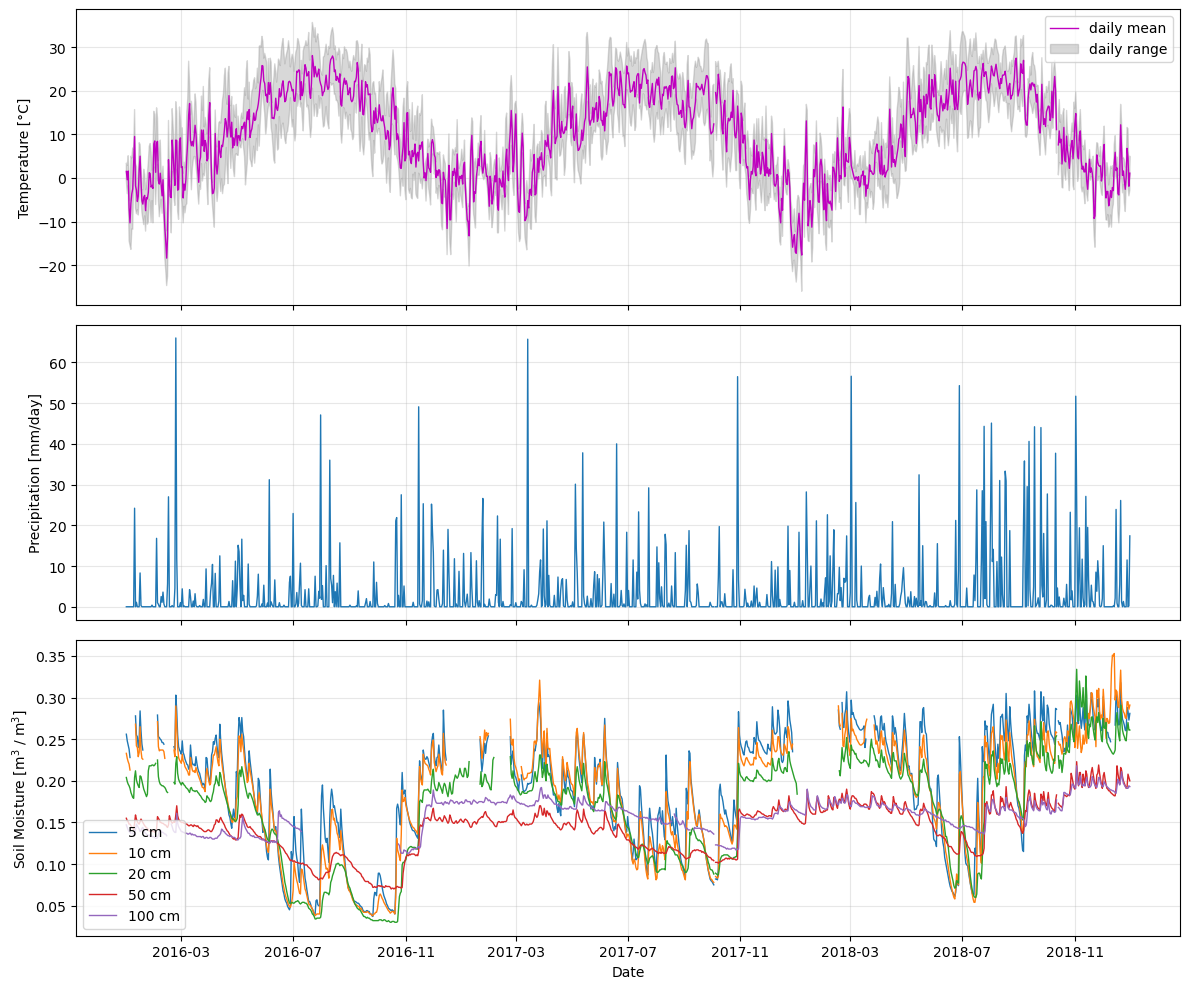

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Top panel: temperature 
axes[0].plot(date, t_daily_mean, color='m', linewidth=1, label='daily mean')
axes[0].fill_between(date, t_daily_min, t_daily_max, color='gray', alpha=0.3, label='daily range')
axes[0].set_ylabel('Temperature [°C]')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Middle panel: precipitation 
axes[1].plot(date, p_daily_calc, linewidth=1)
axes[1].set_ylabel('Precipitation [mm/day]')
axes[1].grid(True, alpha=0.3)

# Bottom panel: soil moisture 
axes[2].plot(date, soil_moisture_5, label='5 cm', linewidth=1)
axes[2].plot(date, soil_moisture_10, label='10 cm', linewidth=1)
axes[2].plot(date, soil_moisture_20, label='20 cm', linewidth=1)
axes[2].plot(date, soil_moisture_50, label='50 cm', linewidth=1)
axes[2].plot(date, soil_moisture_100, label='100 cm', linewidth=1)

axes[2].set_ylabel(r'Soil Moisture [m$^3$ / m$^3$]')
axes[2].set_xlabel('Date')
axes[2].legend(loc='lower left')
axes[2].grid(True, alpha=0.3)

# date formatting
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [5]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


## Problem 2: Contour Plots

In [7]:
pip install netcdf4 pydap

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 53.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 35.4 MB/s  0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━ 4/6 [netcdf4]  WARNING: The scripts nc3tonc4, nc4tonc3 and ncinfo are installed in '/home/yk3149/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [pydap]  WARNING: The scripts dods and pydap are installed in '/home/yk3149/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━

In [2]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays) 
#### NO XARRAY ALLOWED!
#########################################################

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

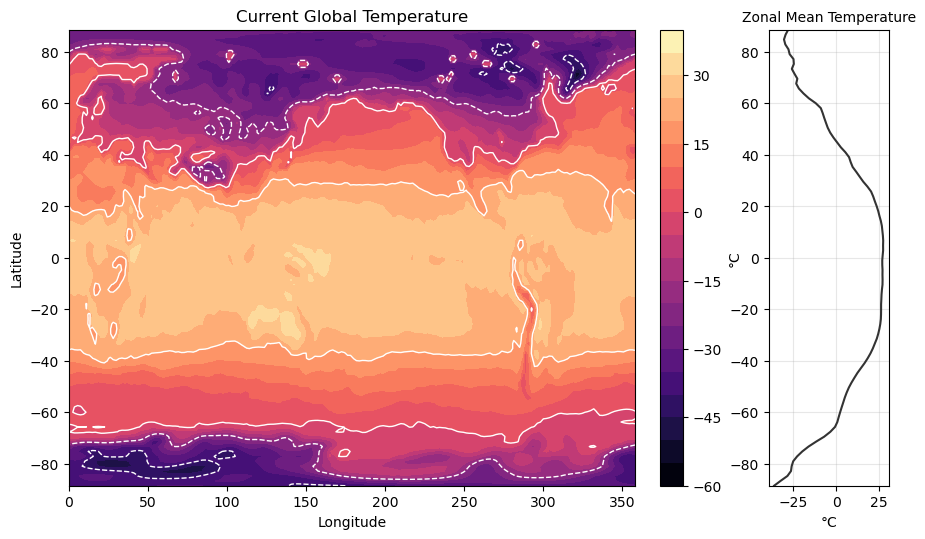

In [5]:
# zonal mean = average over longitude
zonal_mean = temp.mean(axis=1)

fig = plt.figure(figsize=(10, 6))

# left panel
ax1 = fig.add_axes([0.08, 0.12, 0.62, 0.76])
levels = np.arange(-60, 45, 5)

cf = ax1.contourf(lon, lat, temp, levels=levels, cmap='magma')
ax1.contour(lon, lat, temp, levels=[-40, -20, 0, 20], colors='white', linewidths=1)

ax1.set_title('Current Global Temperature')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

cbar = fig.colorbar(cf, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label('°C')

# right panel
ax2 = fig.add_axes([0.78, 0.12, 0.12, 0.76])
ax2.plot(zonal_mean, lat, color='0.2')
ax2.set_title('Zonal Mean Temperature', fontsize=10)
ax2.set_xlabel('°C')
ax2.set_ylim(lat.min(), lat.max())
ax2.grid(True, alpha=0.3)

plt.show()

## Problem 3: Scatter plots

In [8]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

Unzipping contents of '/home/yk3149/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip' to '/home/yk3149/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip.unzip'


/tmp/ipykernel_294640/464612524.py:6: RuntimeWarning: divide by zero encountered in log10
  c=np.log10(depth),


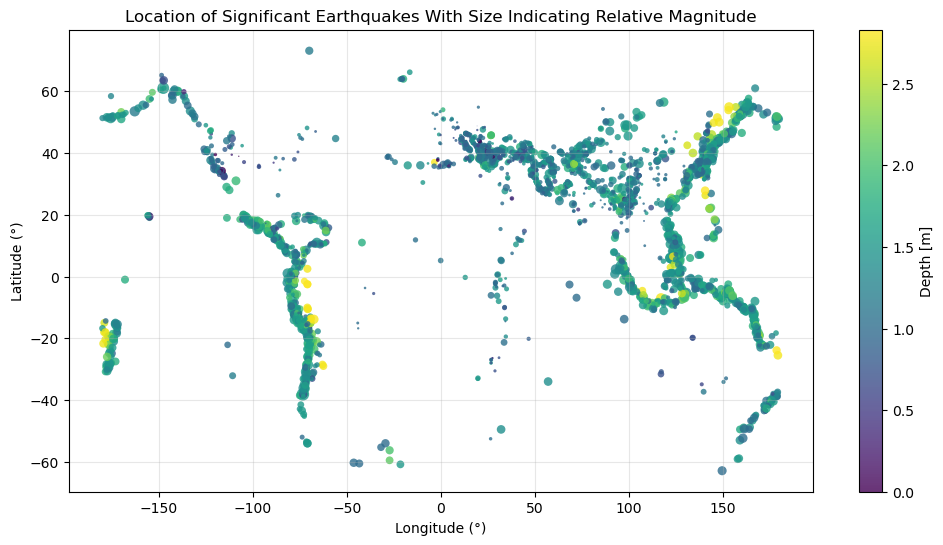

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

sc = ax.scatter(
    longitude,
    latitude,
    c=np.log10(depth),
    s=(magnitude**4) / 100,
    cmap='viridis',
    alpha=0.8,
    edgecolors='none'
)

ax.set_title('Location of Significant Earthquakes With Size Indicating Relative Magnitude')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Depth [m]')

plt.show()